Model Loaded Successfully.
Emotion Labels Loaded Successfully.
Image Loaded Successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Emotion : angry
Confidence : 52.10%


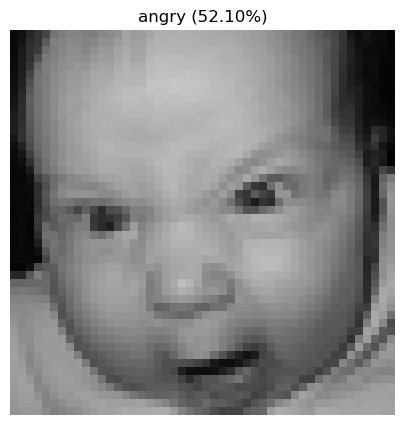

 Single Image Prediction Completed 


In [2]:
# ============================================
# Import Required Libraries
# ============================================

import cv2
import json
import numpy as np

from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt

# ============================================
# Load Trained Model
# ============================================

model = load_model("emotion_model.keras")

with open("emotion_labels.json", "r") as file:
    emotion_labels = json.load(file)

print("Model Loaded Successfully.")
print("Emotion Labels Loaded Successfully.")

# ============================================
# Image Path
# ============================================

image_path = '/Users/nexusop03/Downloads/Emotion/angry/Angry (141).png'

image = cv2.imread(image_path)

if image is None:
    print("Image Not Found!")
else:
    print("Image Loaded Successfully.")

# ============================================
# Image Preprocessing
# ============================================

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray = cv2.resize(gray, (48,48))

gray = gray.astype("float32") / 255.0

gray = gray.reshape(1,48,48,1)


# ============================================
# Predict Emotion
# ============================================

prediction = model.predict(gray)

predicted_index = np.argmax(prediction)

predicted_emotion = emotion_labels[str(predicted_index)]

confidence = np.max(prediction) * 100

print("Predicted Emotion :", predicted_emotion)
print("Confidence : {:.2f}%".format(confidence))


# ============================================
# Display Result
# ============================================

display_image = cv2.imread(image_path)

display_image = cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))

plt.imshow(display_image)

plt.title(f"{predicted_emotion} ({confidence:.2f}%)")

plt.axis("off")

plt.show()


# ============================================
# Prediction Completed
# ============================================

print("="*45)
print(" Single Image Prediction Completed ")
print("="*45)